# 03. Workplace Dynamics & Job Satisfaction

This notebook details workplace dynamics and professional satisfaction. We examine:
1. Remote vs. Hybrid vs. In-person work trends (2021-2025)
2. Workplace setups by organization size
3. Job Satisfaction distributions
4. Relationship between remote work and job satisfaction

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Remote Work Evolution (2021-2025)

Let's trace how the preference for remote/hybrid/in-person has shifted over the last five years.

<Figure size 1200x600 with 0 Axes>

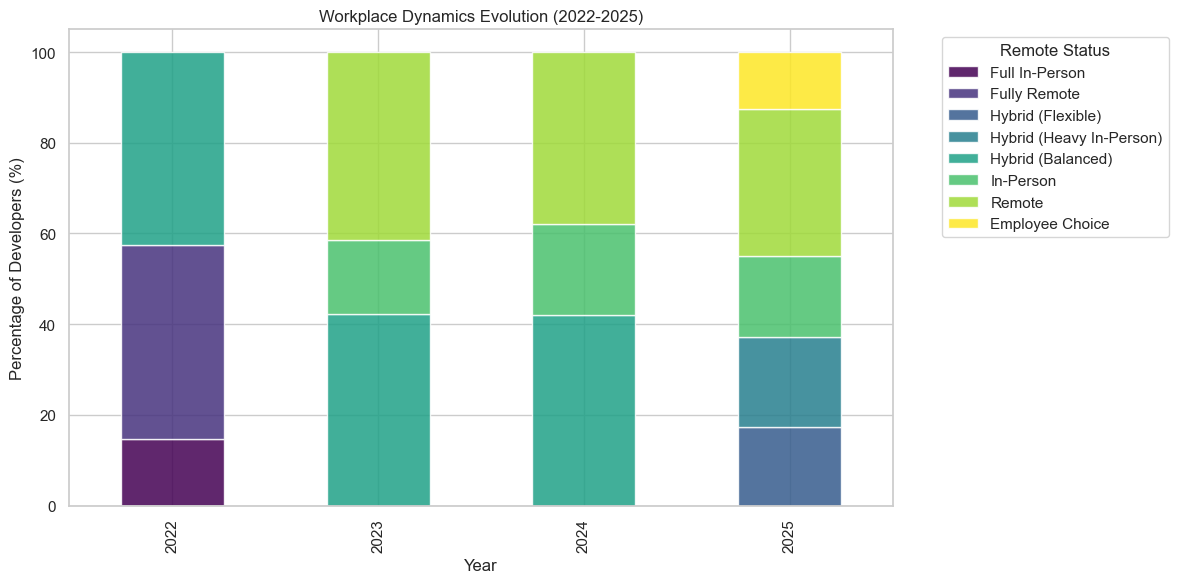

In [ ]:
remote_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    emp.RemoteWork,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
WHERE emp.RemoteWork IS NOT NULL AND emp.RemoteWork <> 'Unknown' AND emp.RemoteWork <> ''
GROUP BY YEAR(f.SurveyYear), emp.RemoteWork;
"""
df_remote = db.read_query(remote_query)

if df_remote is not None and not df_remote.empty:
    df_pivot = df_remote.pivot(index='Year', columns='RemoteWork', values='Count').fillna(0)
    df_pivot_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    label_mapping = {
        'Full in-person': 'Full In-Person',
        'Fully remote': 'Fully Remote',
        'Hybrid (some in-person, leans heavy to flexibility)': 'Hybrid (Flexible)',
        'Hybrid (some remote, leans heavy to in-person)': 'Hybrid (Heavy In-Person)',
        'Hybrid (some remote, some in-person)': 'Hybrid (Balanced)',
        'In-person': 'In-Person',
        'Remote': 'Remote',
        'Your choice (very flexible, you can come in when you want or just as needed)': 'Employee Choice'
    }
    df_pivot_pct = df_pivot_pct.rename(columns=label_mapping)
    plt.figure(figsize=(12, 6))
    ax = df_pivot_pct.plot(kind='bar', stacked=True,alpha=0.85, colormap='viridis')
    
    plt.title('Workplace Dynamics Evolution (2022-2025)')
    plt.xlabel('Year')
    plt.ylabel('Percentage of Developers (%)')
    plt.xticks(rotation=90) 
    
    plt.legend(title='Remote Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_remote_work_trends.png'), dpi=300)
    plt.show()
else:
    print("No remote work data available.")

### 2. Workplace Setting by Organization Size (2025)

Do larger companies require more in-person work than small businesses?

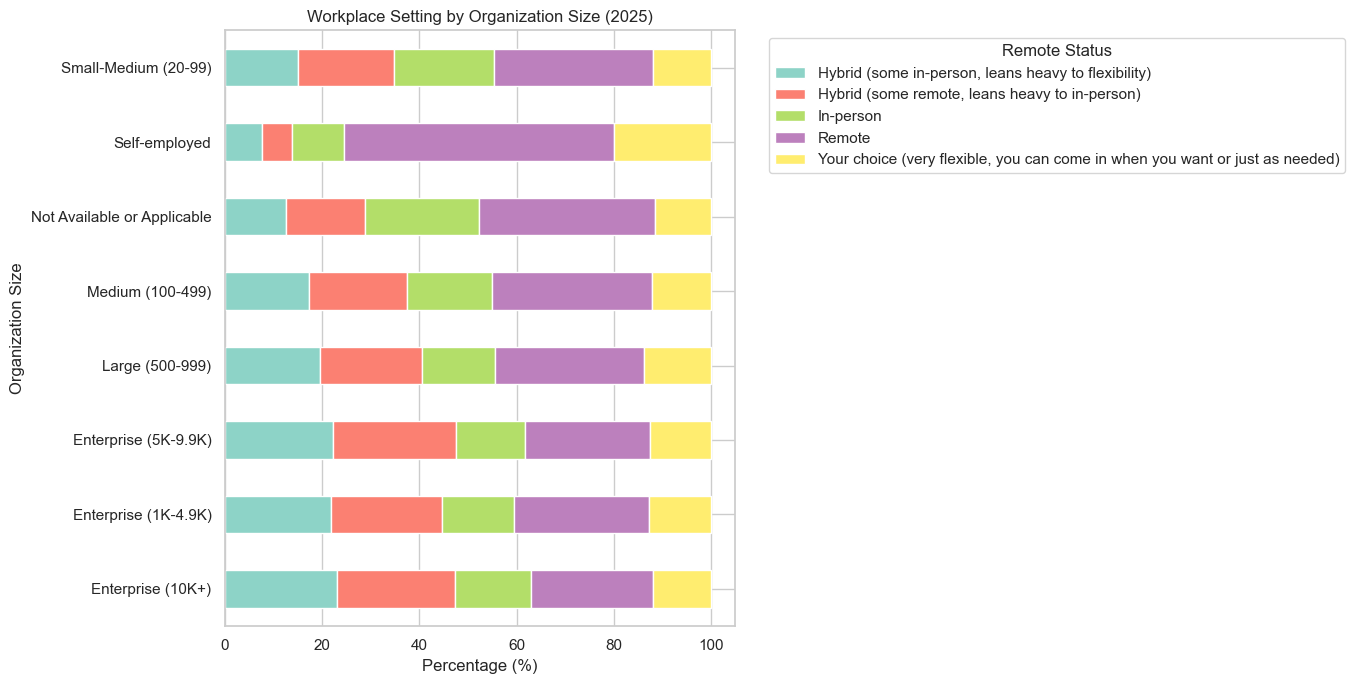

In [ ]:
org_work_query = """
SELECT 
    emp.Organization_Size,
    emp.RemoteWork,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
WHERE YEAR(f.SurveyYear) = 2025
  AND emp.RemoteWork IS NOT NULL AND emp.RemoteWork <> 'Unknown' AND emp.RemoteWork <> ''
  AND emp.Organization_Size IS NOT NULL AND emp.Organization_Size <> 'Unknown' AND emp.Organization_Size <> ''
GROUP BY emp.Organization_Size, emp.RemoteWork;
"""
df_org_work = db.read_query(org_work_query)

if df_org_work is not None and not df_org_work.empty:
    df_org_pivot = df_org_work.pivot(index='Organization_Size', columns='RemoteWork', values='Count').fillna(0)
    # Order by size
    size_order = ['Enterprise (10K+)' ,
                'Enterprise (1K-4.9K)' ,
                'Enterprise (5K-9.9K)',
                'Large (500-999)','Medium (100-499)' ,
                'Not Available or Applicable',
                'Self-employed' ,
                'Small-Medium (20-99)'
                ]
    df_org_pivot = df_org_pivot.reindex(size_order).dropna()
    df_org_pct = df_org_pivot.div(df_org_pivot.sum(axis=1), axis=0) * 100
    
    df_org_pct.plot(kind='barh', stacked=True, figsize=(14, 7), colormap='Set3')
    plt.title('Workplace Setting by Organization Size (2025)')
    plt.xlabel('Percentage (%)')
    plt.ylabel('Organization Size')
    
    df_pivot_pct = df_pivot_pct.rename(columns=label_mapping)
    plt.legend(title='Remote Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_remote_by_org_size.png'), dpi=300)
    plt.show()
else:
    print("No remote/org data available.")

### 3. Job Satisfaction Distribution

How satisfied are developers with their current roles overall?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


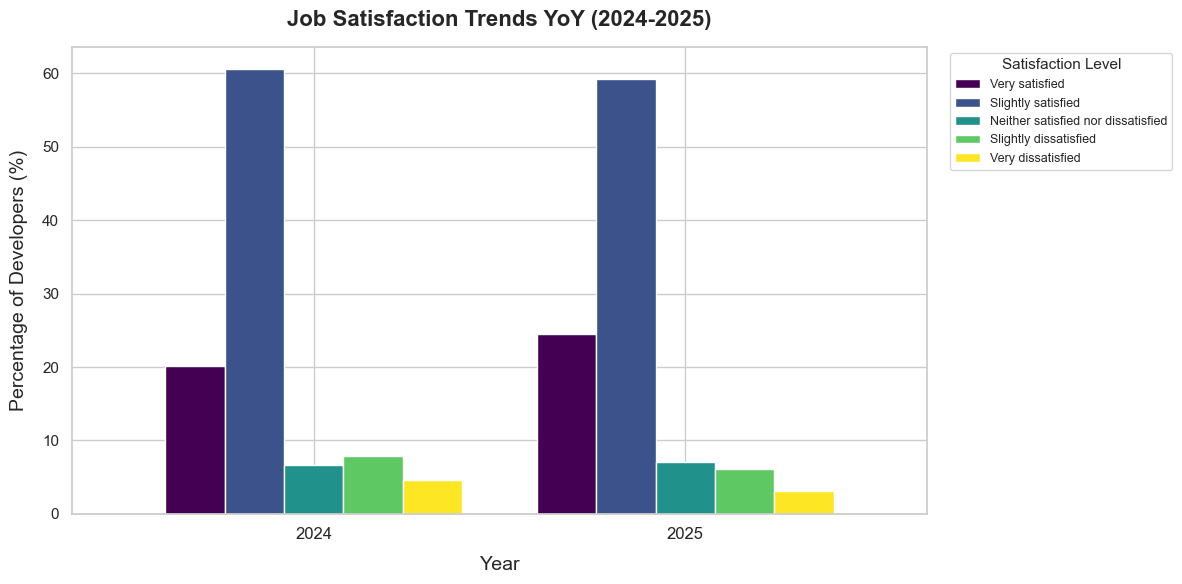

In [24]:
sat_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    sat.JobSat,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Satisfaction sat ON f.Dim_SatisfactionID = sat.Dim_SatisfactionID
WHERE sat.JobSat IS NOT NULL AND sat.JobSat <> 'Unknown' AND sat.JobSat <> '' and 
Year(f.SurveyYear) in (2024,2025)
GROUP BY YEAR(f.SurveyYear), sat.JobSat;
"""
df_sat = db.read_query(sat_query)
if df_sat is not None and not df_sat.empty:
    df_sat_all = df_sat.copy()
    
    sat_mapping = {
        '10': 'Very satisfied', '9': 'Very satisfied',
        '8': 'Slightly satisfied', '7': 'Slightly satisfied', '6': 'Slightly satisfied',
        '5': 'Neither satisfied nor dissatisfied',
        '4': 'Slightly dissatisfied', '3': 'Slightly dissatisfied',
        '2': 'Very dissatisfied', '1': 'Very dissatisfied', '0': 'Very dissatisfied'
    }
    
    df_sat_all['JobSat_Group'] = df_sat_all['JobSat'].astype(str).map(sat_mapping)
    df_grouped = df_sat_all.groupby(['Year', 'JobSat_Group'])['Count'].sum().reset_index()
    
    df_pivot = df_grouped.pivot(index='Year', columns='JobSat_Group', values='Count').fillna(0)
    
    df_pivot_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    
    order = [
        'Very satisfied', 
        'Slightly satisfied', 
        'Neither satisfied nor dissatisfied', 
        'Slightly dissatisfied', 
        'Very dissatisfied'
    ]
    df_pivot_pct = df_pivot_pct.reindex(columns=order)
    
    plt.figure(figsize=(12, 6))
    ax = df_pivot_pct.plot(kind='bar', ax=plt.gca(), colormap='viridis', width=0.8)
    
    plt.title('Job Satisfaction Trends YoY (2024-2025)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Year', fontsize=14, labelpad=10)
    plt.ylabel('Percentage of Developers (%)', fontsize=14, labelpad=10)
    
    plt.xticks(rotation=0, fontsize=12)
    plt.yticks(fontsize=11)
    
    plt.legend(title='Satisfaction Level', title_fontsize=11, fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_job_satisfaction_yoy.png'), dpi=300)
    plt.show()
else:
    print("No satisfaction data available.")

### 4. Job Satisfaction vs. Workplace Setup

Does remote work have a correlation with job satisfaction?

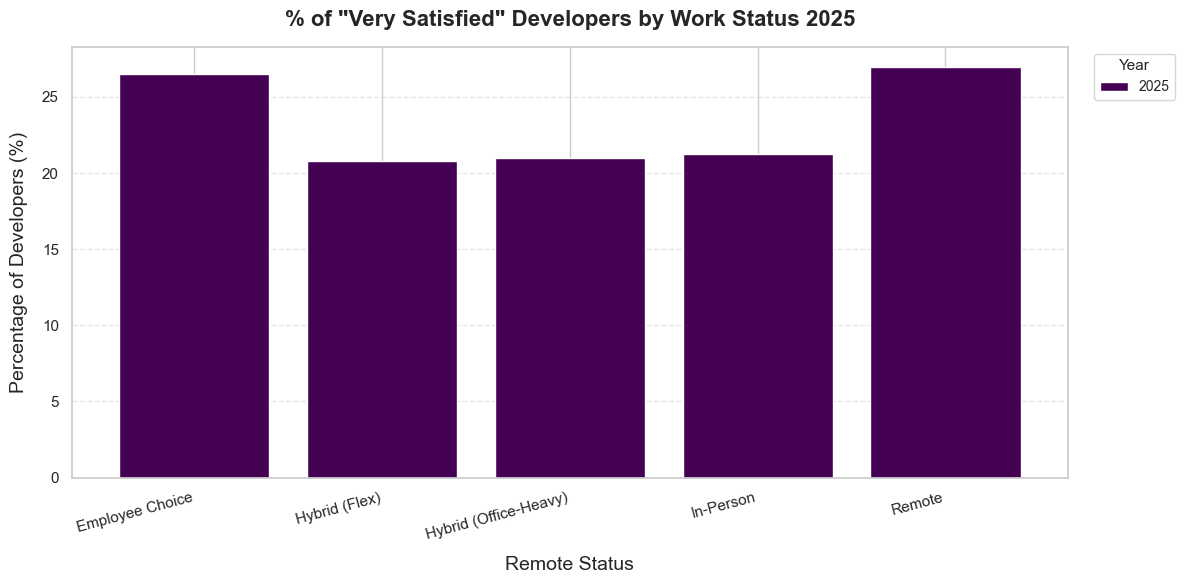

In [ ]:
remote_sat_query = """
SELECT 
    Year(f.SurveyYear) as Year,
    emp.RemoteWork,
    sat.JobSat,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Employment emp ON f.Dim_EmploymentID = emp.Dim_EmploymentID
JOIN Snowflake.Dim_Satisfaction sat ON f.Dim_SatisfactionID = sat.Dim_SatisfactionID
  AND emp.RemoteWork IS NOT NULL AND emp.RemoteWork <> 'Unknown'
  AND sat.JobSat IS NOT NULL AND sat.JobSat <> 'Unknown'
  AND Year(f.SurveyYear) = 2025
GROUP BY Year(f.SurveyYear),emp.RemoteWork, sat.JobSat;
"""
df_remote_sat = db.read_query(remote_sat_query)

if df_remote_sat is not None and not df_remote_sat.empty:
    df_chart = df_remote_sat.copy()
    
    remote_mapping = {
        'Full in-person': 'In-Person',
        'Fully remote': 'Remote',
        'Hybrid (some in-person, leans heavy to flexibility)': 'Hybrid (Flex)',
        'Hybrid (some remote, leans heavy to in-person)': 'Hybrid (Office-Heavy)',
        'Hybrid (some remote, some in-person)': 'Hybrid (Balanced)',
        'In-person': 'In-Person',
        'Remote': 'Remote',
        'Your choice (very flexible, you can come in when you want or just as needed)': 'Employee Choice'
    }
    df_chart['RemoteWork_Clean'] = df_chart['RemoteWork'].map(remote_mapping).fillna(df_chart['RemoteWork'])

    sat_mapping = {
        '10': 'Very satisfied', '9': 'Very satisfied',
        '8': 'Slightly satisfied', '7': 'Slightly satisfied', '6': 'Slightly satisfied',
        '5': 'Neither satisfied nor dissatisfied',
        '4': 'Slightly dissatisfied', '3': 'Slightly dissatisfied',
        '2': 'Very dissatisfied', '1': 'Very dissatisfied', '0': 'Very dissatisfied'
    }
    df_chart['JobSat_Group'] = df_chart['JobSat'].astype(str).map(sat_mapping)
    
    df_grouped = df_chart.groupby(['Year', 'RemoteWork_Clean', 'JobSat_Group'])['Count'].sum().reset_index()
    
    df_pivot = df_grouped.pivot_table(index=['RemoteWork_Clean', 'Year'], columns='JobSat_Group', values='Count', aggfunc='sum').fillna(0)
    df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
    
    df_bar_data = df_pct['Very satisfied'].unstack(level='Year').fillna(0)
    
    plt.figure(figsize=(12, 6))
    ax = df_bar_data.plot(kind='bar', width=0.8, colormap='viridis', ax=plt.gca())
    
    plt.title('% of "Very Satisfied" Developers by Work Status 2025', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Remote Status', fontsize=14, labelpad=10)
    plt.ylabel('Percentage of Developers (%)', fontsize=14, labelpad=10)
    
    plt.xticks(rotation=15, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    plt.legend(title='Year', title_fontsize=11, fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '03_satisfaction_year_bar.png'), dpi=300)
    plt.show()
else:
    print("No data available.")

In [ ]:
db.close()